# Expert Knowledge Integration with Causal Discovery

Causal Discovery (aka. Structure learning) seeks to uncover the causal relationships among random variables from observational datasets. Methods like the PC algorithm and Hill-climb Search can be used for causal discovery, however, they often struggle to recover the correct causal relationships due to issues such as data not satisfying the assumptions of the method, limited data can lead to error, high compute time when there are many variables or the model is dense.

Incorporating expert knowledge can greatly improve the accuracy of these methods, as well as reduce the computational cost as it constrains the search space for these algorithms. 

This tutorial walks through examples of specifying expert knowledge with the causal discovery algorithms implemented in pgmpy. Expert knowledge is supported in pgmpy with the following algorithms:

- **PC**
- **Hill Climb Search**
- **GES**
- **MMHC**
- **ExpertInLoop**

The models used in this notebook are described in detail at [the bnlearn repository](https://www.bnlearn.com/bnrepository/).


### Expert knowledge with the PC Algorithm

In [1]:
# Imports and configuration
import logging
import time

from IPython.display import display
from pgmpy.utils import get_example_model
from pgmpy.global_vars import logger

logger.setLevel(logging.ERROR)

  0%|          | 0/5 [00:00<?, ?it/s]

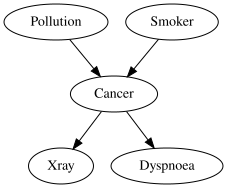

In [2]:
# Load an example model and simulate data from it.
cancer = get_example_model("cancer")
cancer_samples = cancer.simulate(n_samples=5000, seed=42)

# Plot the `cancer` model
diag = cancer.to_graphviz()
diag.layout(prog="dot")
display(diag)

  0%|          | 0/5 [00:00<?, ?it/s]

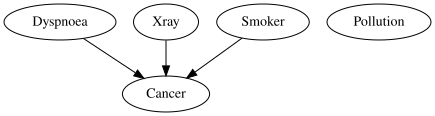

In [3]:
# Run the standard PC algorithm and plot the results

from pgmpy.estimators import PC, ExpertKnowledge

learned_model = PC(cancer_samples).estimate()

diag = learned_model.to_graphviz()
diag.layout(prog="dot")
display(diag)

As seen from the learned model, the PC algorithm was not able to correctly recover the original data-generating DAG. 

Now, we know that smoking (`Smoker`) and air pollution (`Pollution`) contribute to lung cancer (`Cancer`). Also, breathing difficulties (`Dyspnoea`) and a positive X-ray report (`Xray`) contribute to a cancer diagnosis (effect), so they cannot be the initial causes in this scenario. Based on this, we can craft a temporal order where the causes of cancer are at a higher temporal order, while the effects are lumped together at the end.

  0%|          | 0/5 [00:00<?, ?it/s]

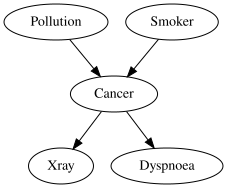

In [4]:
# PC algorithm with the temporal knowledge.

expert_knowledge = ExpertKnowledge(
    temporal_order=[["Pollution", "Smoker"], ["Cancer"], ["Dyspnoea", "Xray"]]
)

est_model = PC(cancer_samples).estimate(expert_knowledge=expert_knowledge)

diag = est_model.to_graphviz()
diag.layout(prog="dot")
display(diag)

Note: Using any form of expert knowledge, especially with PC, is sensitive to the accuracy of the knowledge.

### Integrating with different algorithms

  0%|          | 0/48 [00:00<?, ?it/s]

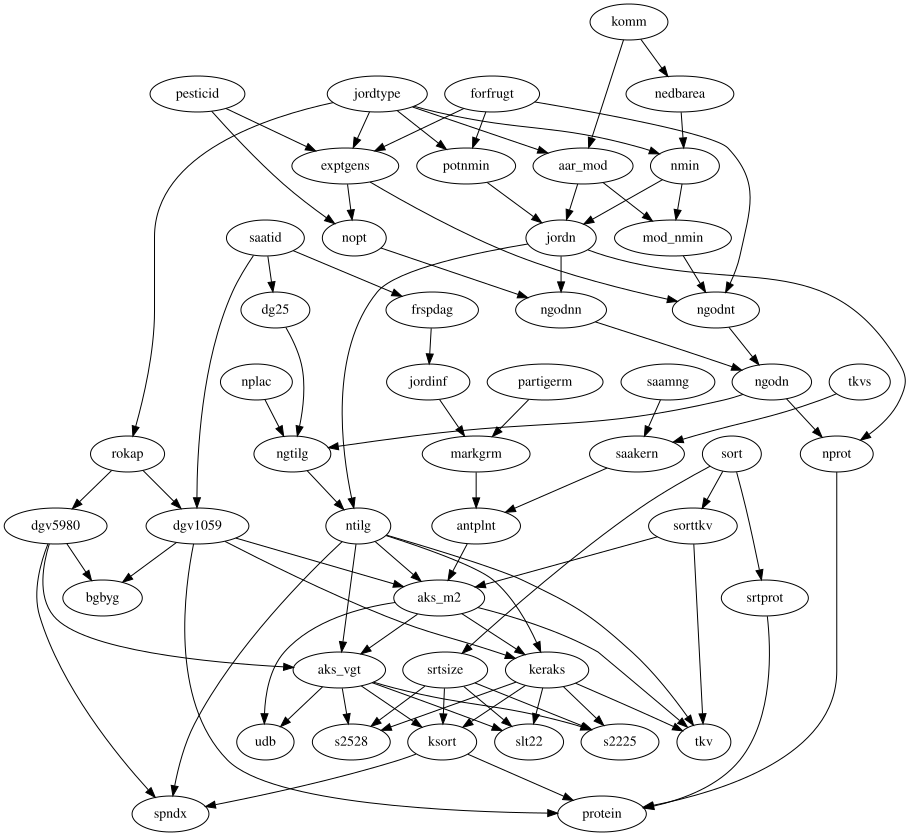

In [5]:
barley = get_example_model("barley")
barley_samples = barley.simulate(n_samples=5000, seed=42)

diag = barley.to_graphviz()
diag.layout(prog="dot")
display(diag)

In [6]:
from pgmpy.metrics import SHD

t1 = time.time()
est_model = PC(barley_samples).estimate(show_progress=False)
t2 = time.time()

print(f"Time elapsed: {t2-t1} seconds")

shd = SHD(barley, est_model)
print(f"SHD: {shd}")

Time elapsed: 36.04804229736328 seconds
SHD: 63


Combined approach

An alternative approach could be to first get a skeleton using the first phase of PC. The skeleton is simply the set of edges between nodes that are dependent(causal). This skeleton can be used as the search space for score-based methods like Hill Climb Search, thus reducing the workload in this phase (as we have already removed edges that are independent given some conditioning set). We get a reasonable result as compared to using only PC.

In [7]:
from pgmpy.estimators import HillClimbSearch

t1 = time.time()
skeleton, sep_sets = PC(barley_samples).estimate(return_type="skeleton")

expert_knowledge = ExpertKnowledge(search_space=skeleton.edges)
est_model = HillClimbSearch(barley_samples).estimate(expert_knowledge=expert_knowledge)
t2 = time.time()
shd = SHD(barley, est_model)

print(f"Time elapsed: {t2-t1} seconds")
print(f"SHD: {shd}")

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

Time elapsed: 37.988627433776855 seconds
SHD: 67


### Knowledge base of required and forbidden edges

  0%|          | 0/20 [00:00<?, ?it/s]

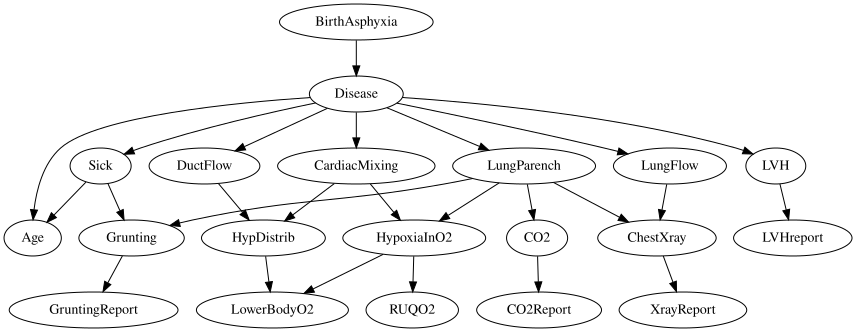

In [8]:
child = get_example_model("child")
child_samples = child.simulate(n_samples=1000, seed=42)

diag = child.to_graphviz()
diag.layout(prog="dot")
display(diag)

Based on similar reasoning as in the first section, we can now create a knowledge base consisting of forbidden and required edges. For example, having birth asphyxia ('Disease') directly contributes to the 6 subclassses/markers of disease ('LVH', 'LungParench' etc.). Similarly, the CO2 level ('CO2') affects the CO2 report ('CO2Report'), and not the other way around.

In [9]:
required_edges = [
    ("Disease", "Sick"),
    ("Disease", "DuctFlow"),
    ("Disease", "LungFlow"),
    ("Disease", "LungParench"),
    ("CO2", "CO2Report"),
]
forbidden_edges = [
    ("CO2Report", "CO2"),
    ("LVH", "Disease"),
    ("Disease", "BirthAsphyxia"),
]

expert_knowledge = ExpertKnowledge(
    required_edges=required_edges, forbidden_edges=forbidden_edges
)
est_model = HillClimbSearch(child_samples).estimate(
    expert_knowledge=expert_knowledge, scoring_method="k2"
)
SHD(child, est_model)

  0%|          | 0/1000000 [00:00<?, ?it/s]

4

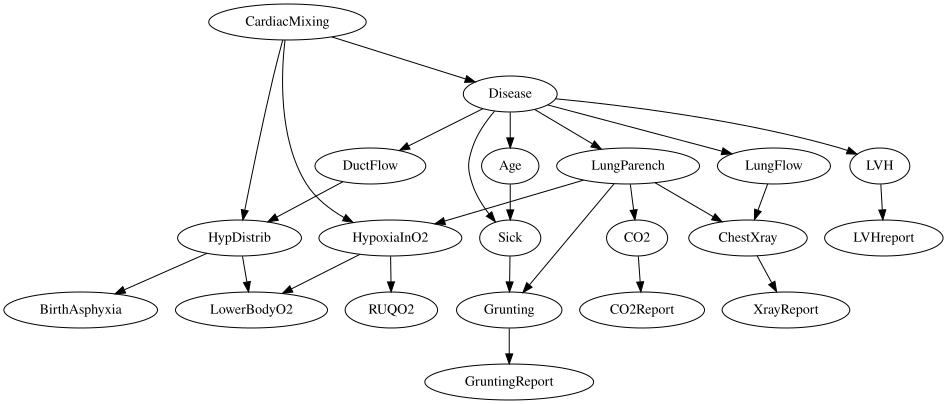

In [10]:
diag = est_model.to_graphviz()
diag.layout(prog="dot")
display(diag)